# Modeling Evaluation

The training compares three models:

1. Logistic Regression
2. XGBoost
3. LightGBM

The selected model is chosen using validation PR-AUC because the positive class is relatively small. Accuracy is still reported, but it should not be the main decision metric.


## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    confusion_matrix,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Project root:", PROJECT_ROOT)
print("Reports path exists:", REPORTS_DIR.exists())

Project root: /Users/morenomusadat/Downloads/bank-campaign-targeting-system
Reports path exists: True


## 2. Load Model Training Outputs

In [3]:
validation_comparison = pd.read_csv(REPORTS_DIR / "validation_model_comparison.csv")
final_test_metrics = pd.read_csv(REPORTS_DIR / "final_model_test_metrics.csv")
model_results_summary = pd.read_csv(REPORTS_DIR / "model_results_summary.csv")
selected_model_summary = pd.read_csv(REPORTS_DIR / "selected_model_summary.csv")
validation_predictions = pd.read_csv(REPORTS_DIR / "final_model_validation_predictions.csv")
test_predictions = pd.read_csv(REPORTS_DIR / "final_model_test_predictions.csv")

feature_importance_path = REPORTS_DIR / "feature_importance.csv"

if feature_importance_path.exists():
    feature_importance = pd.read_csv(feature_importance_path)
else:
    feature_importance = pd.DataFrame()

display(validation_comparison)
display(selected_model_summary)
display(final_test_metrics)

,model_name,split,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
0,xgboost,validation,0.834518,0.376923,0.639130,0.474194,0.802105,0.475573,0.5
1,lightgbm,validation,0.841624,0.389189,0.626087,0.480000,0.797140,0.470489,0.5
2,logistic_regression,validation,0.823858,0.358696,0.645652,0.461180,0.791972,0.446073,0.5


,selected_model,selection_metric,validation_pr_auc,test_pr_auc,test_roc_auc,default_threshold
0,xgboost,validation_pr_auc,0.475573,0.522748,0.803411,0.5


,model_name,split,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
0,xgboost,test,0.833291,0.376101,0.65,0.476494,0.803411,0.522748,0.5


**Interpretation:**

The model has good ranking ability, shown by ROC-AUC around 0.80 and PR-AUC around 0.52. Since the positive class is only around 11.7%, a PR-AUC of 0.52 is meaningfully above the baseline positive rate. That means the model is learning useful patterns for identifying likely subscribers.

## 3. Validation Model Comparison

This table compares the baseline model and the two boosted tree models on the validation set.

In [4]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

display(
    validation_comparison[
        ["model_name"] + metric_cols
    ].sort_values("pr_auc", ascending=False)
)

,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc
0,xgboost,0.834518,0.376923,0.639130,0.474194,0.802105,0.475573
1,lightgbm,0.841624,0.389189,0.626087,0.480000,0.797140,0.470489
2,logistic_regression,0.823858,0.358696,0.645652,0.461180,0.791972,0.446073


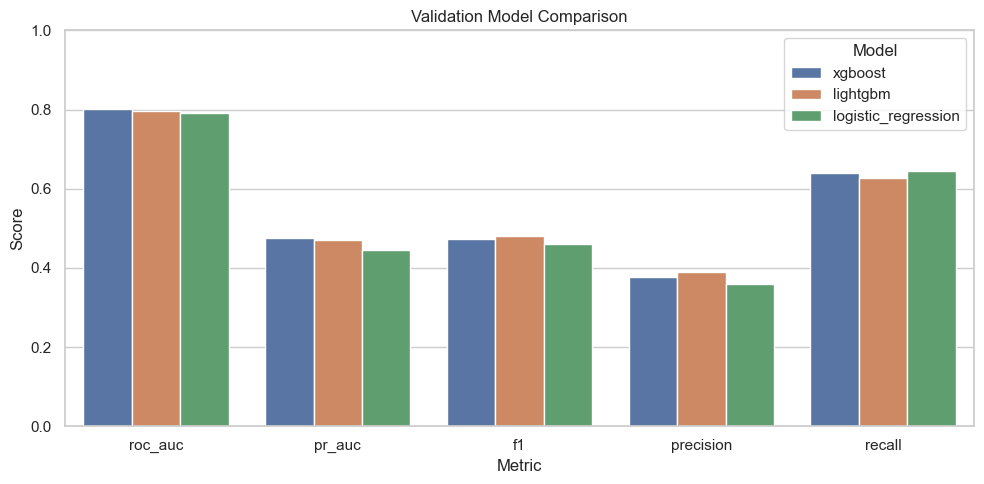

In [5]:
plot_data = validation_comparison.melt(
    id_vars=["model_name"],
    value_vars=["roc_auc", "pr_auc", "f1", "precision", "recall"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="model_name")
plt.title("Validation Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

**Interpretation:**

The selected metric is PR-AUC, not accuracy or F1. Because this is an imbalanced targeting problem, PR-AUC is more relevant than accuracy. Accuracy can look high simply because most customers do not subscribe.

All three models are reasonably close, but the boosted-tree models perform better than Logistic Regression on PR-AUC. This suggests nonlinear models are capturing useful patterns beyond the linear baseline.

XGBoost is selected because it ranks likely subscribers slightly better than the other models. LightGBM is very close and even better on F1, so the correct interpretation is not “XGBoost is clearly superior,” but “XGBoost is the best model under the chosen validation PR-AUC rule.”

## 4. Selected Model Test Performance


In [6]:
selected_model = selected_model_summary.loc[0, "selected_model"]
print("Selected model:", selected_model)

display(final_test_metrics[["model_name"] + metric_cols])

Selected model: xgboost


,model_name,accuracy,precision,recall,f1,roc_auc,pr_auc
0,xgboost,0.833291,0.376101,0.65,0.476494,0.803411,0.522748


## 5. Confusion Matrix at Default Threshold

The threshold used here is 0.5. This is only an initial technical threshold.

For campaign targeting, the later threshold simulation step is more important because the business may choose to contact only the top-scored customers.


,Predicted No,Predicted Yes
Actual No,2985,496
Actual Yes,161,299


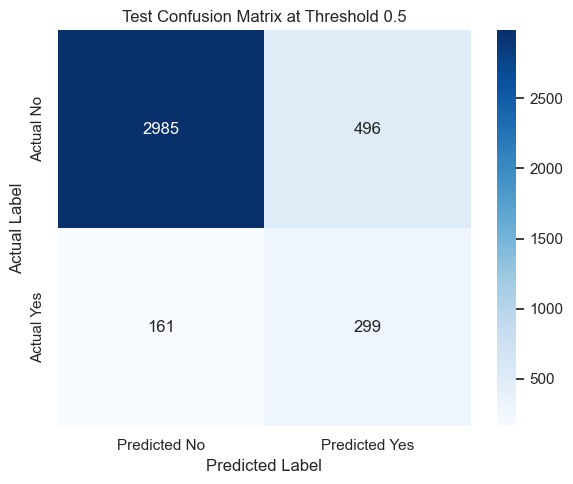

In [7]:
y_true = test_predictions["y_true"]
y_pred = test_predictions["predicted_label_0_5"]

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"],
)

display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix at Threshold 0.5")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

**Interpretation:**

The confusion matrix shows the model is recall-oriented at threshold 0.5. It catches many subscribers but also creates a meaningful number of false positives. For campaign targeting, this is acceptable only if the cost of extra contact is manageable.

---

At threshold 0.5, the model predicts --> 496 + 299 = 795 customers as likely subscribers.

Out of the test set, the model would recommend contacting about 795 / 3941 =  ~20.2% of customers

It captures --> 299 / 460 = 65.0% of all actual subscribers in the test set.

---

## 6. Predicted Probability Distribution

This plot checks whether the model gives higher probabilities to actual subscribers more often than to non-subscribers.
This was done because a campaign targeting model should be useful for ranking customers, not only assigning a default class label.

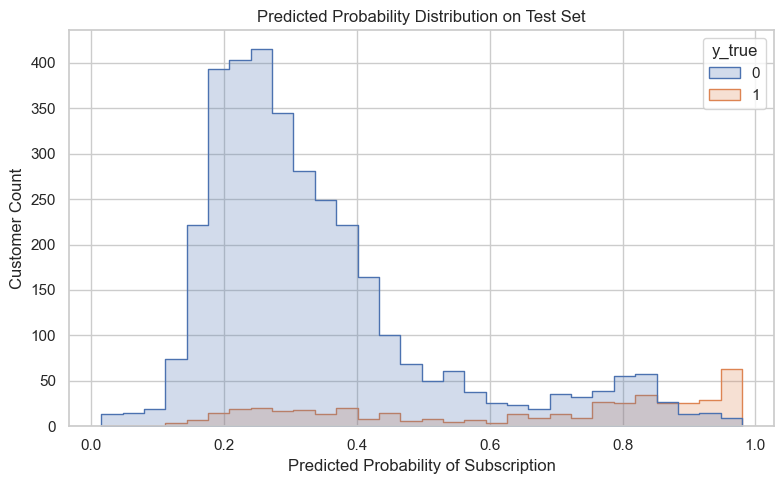

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=test_predictions,
    x="predicted_probability",
    hue="y_true",
    bins=30,
    kde=False,
    element="step",
    stat="count",
)
plt.title("Predicted Probability Distribution on Test Set")
plt.xlabel("Predicted Probability of Subscription")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

**Interpretation:**

The graph shows predicted probability distributions for:

0 = non-subscriber
1 = subscriber

This graph shows that non-subscribers are mostly concentrated around lower probabilities, especially around 0.15 to 0.40. Subscribers are more spread out, with many appearing at higher probabilities, including around 0.70 to 0.95. But there is still overlap between subscribers and non-subscribers.

This graph also supports the idea that the model should be used as a ranking tool. Customers with higher predicted probability are more promising, but not guaranteed to subscribe. The model was able to provide useful probability separation, but there is overlap between classes. This means the model is helpful for prioritization, not perfect classification.

## 7. ROC and Precision-Recall Curves

ROC-AUC shows general ranking ability across thresholds & PR-AUC is especially useful here because the positive class is much smaller than the negative class.


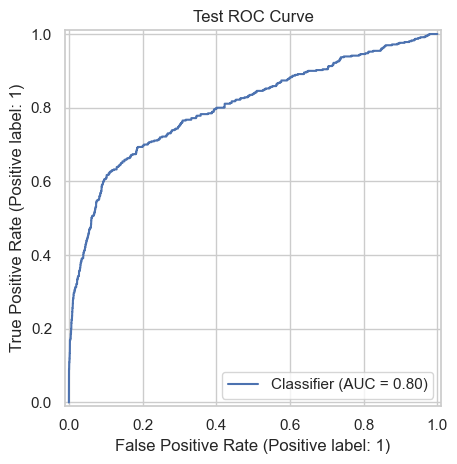

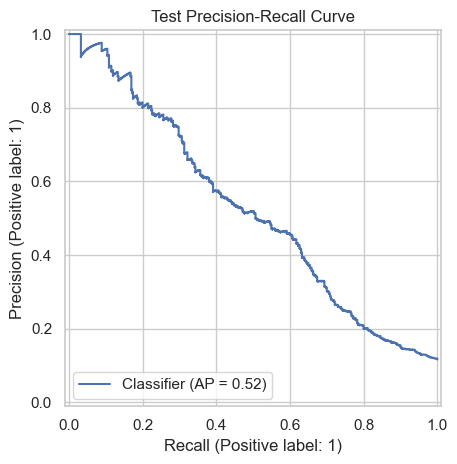

In [9]:
y_true = test_predictions["y_true"]
y_score = test_predictions["predicted_probability"]

RocCurveDisplay.from_predictions(y_true, y_score)
plt.title("Test ROC Curve")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_true, y_score)
plt.title("Test Precision-Recall Curve")
plt.tight_layout()
plt.show()

**Interpretation:**

1. The ROC curve gives:

    AUC = 0.80

    This means the model has good general ranking ability. Simply speaking, when comparing one subscriber and one non-subscriber, the model often gives the subscriber a higher score.
    <br><br>
2. The Precision-Recall curve gives:

    Average Precision = 0.52

    Since the dataset is imbalanced, only around 11.7% of customers subscribe, a PR-AUC around 0.52 is much better than random baseline.

Overall, the ROC curve confirms general separability. The PR curve confirms the model is useful even under class imbalance. However, the PR curve also shows the tradeoff clearly: as recall increases, precision falls. That means capturing more subscribers requires contacting more non-subscribers too.

## 8. Feature Importance

This section shows the top features from the selected model.


,model_name,feature,importance,importance_type
0,xgboost,numerical__nr.employed,0.355882,feature_importance
1,xgboost,numerical__emp.var.rate,0.095123,feature_importance
2,xgboost,numerical__was_previously_contacted,0.045133,feature_importance
3,xgboost,categorical__month_oct,0.030390,feature_importance
4,xgboost,categorical__poutcome_success,0.027533,feature_importance
5,xgboost,numerical__cons.conf.idx,0.025941,feature_importance
6,xgboost,categorical__month_mar,0.022843,feature_importance
7,xgboost,numerical__cons.price.idx,0.020864,feature_importance
8,xgboost,numerical__euribor3m,0.017993,feature_importance
9,xgboost,categorical__contact_telephone,0.016391,feature_importance


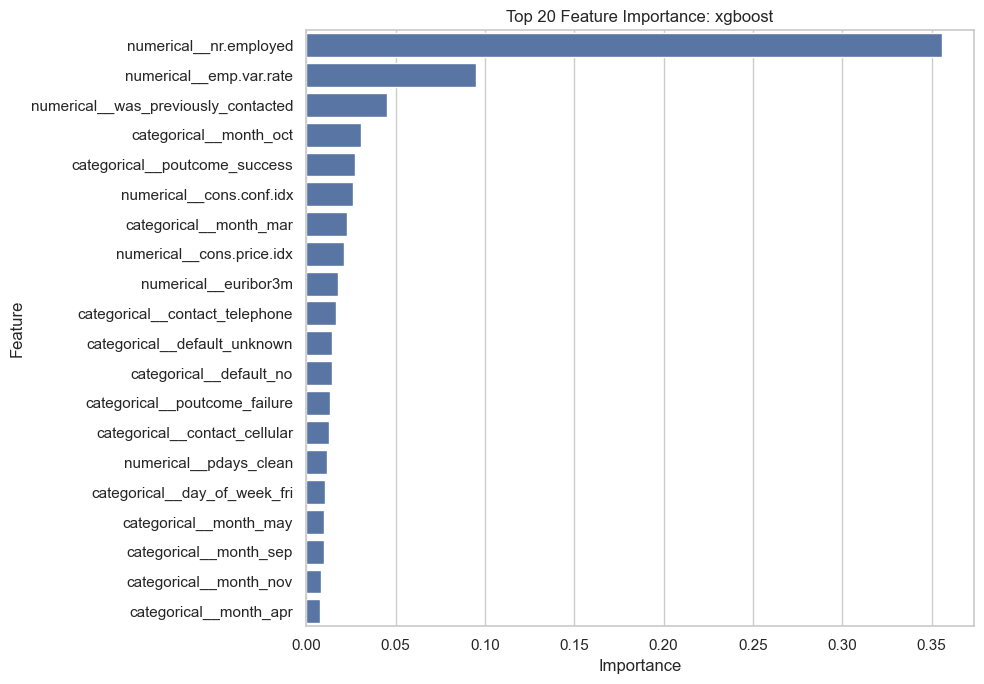

In [10]:
if not feature_importance.empty:
    display(feature_importance.head(20))

    top_features = feature_importance.head(20).copy()

    plt.figure(figsize=(10, 7))
    sns.barplot(data=top_features, x="importance", y="feature")
    plt.title(f"Top 20 Feature Importance: {selected_model}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance file was not found or not available for this model.")

**Interpretation:**

The model is not only learning customer demographics. It is heavily learning campaign timing, macroeconomic conditions, and previous campaign history.